# Mathematical Foundations of Computer Graphics and Vision 2023
## Exercise 1 - Robust Estimation and Optimization

In this exercise you will apply what you learned about robust optimization, especially RANSAC and Iteratively Reweighted Least Squares (IRLS). You will implement RANSAC for circle fitting in the presence of outliers, IRLS for line fitting with $L_1$ norm, and LP for line fitting with $L_1$ and $L_\infty$ norms.

We have implemented a skeleton notebook and you have to fill out blocks marked with `TODO`. Please refrain from modifying the notebook outside of the `START` and `END` blocks for the coding problems apart from new cells you create.

<b style="color:red">Use numpy vectorization</b> instead of python loops where explicitly noted. We may deduct points if your code runs unreasonably slow due (see the "test case" cell).

In [1]:
%matplotlib inline
import math
from typing import Tuple, List, Optional
import itertools
from collections import namedtuple

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt


np.random.seed(123)

## Part 1: RANSAC for circle fitting

In [2]:
# Default parameters
N = 100  # number of total points
D = 10  # half-domain size
tau = 0.1  # inlier distance threshold

### 1.1. Data Generation and Model Fitting

In [3]:
class Polynomial:
    def __init__(self, coefficients):
        self._coefficients = coefficients

    def __repr__(self):
        return f"Polynomial({self._coefficients.tolist()})"

    @property
    def degree(self):
        return len(self._coefficients) - 1

    def evaluate(self, x):
        """
        x - (N,1) array with the `x` coordinates

        Returns - (N,1) array with their `y` coordinates
        """

        #y = np.ones_like(x)

        # TODO: evaluate the polynomial at points x
        # Use numpy vectorization!
        # START
        exponents = np.arange(0, self.degree+1, 1)
        x_to_deg = x**exponents
        y = x_to_deg @ self._coefficients[:, np.newaxis]
        # END

        return y

    def is_inlier(self, points: np.ndarray, threshold: float = tau):
        """
        points - Nx2 array with the data points

        Returns - bool vector of size N, where i-th element indicates if i-th point of `points` is an inlier
        """
        #is_inlier = np.ones((points.shape[0],), dtype=bool)

        # TODO : Fill vector `is_inlier`, for i-th element to indicate if i-th point of `points` is an inlier
        # Use `self.evaluate`
        # Use numpy vectorization!
        # START
        x_col = points[:,0].reshape(-1,1)
        y_col = points[:,1].reshape(-1,1)

        x_eval = self.evaluate(x_col)
        abs_diff = np.abs(y_col-x_eval)
        is_inlier = abs_diff <= tau
        # END

        return np.squeeze(is_inlier)

    def generate_points(self, r: float, n_points: int = N) -> Tuple[np.ndarray, np.ndarray]:
        """
        r - outlier ratio
        n_points - number of points to generate

        Returns - tuple of inliers and outliers, each defined as an Nx2 array of the respective points
        """
        n_outliers = int(n_points * r)
        n_inliers = n_points - n_outliers

        #inliers = np.random.uniform(-D, D, (n_inliers, 2))
        #outliers = np.random.uniform(-D, D, (n_outliers, 2))

        # TODO : Implement Task 1.1. Make use of `self.evaluate` and `self.is_inlier` for that
        # START
        #inliers_x = np.random.uniform(-D, D, (n_inliers, 1))

        #generate x coordinates inside domain and use self.evaluate() plus random
        #uniform noise to generate y coordinates. Only add to the inliers's list
        #when the point is inside the domain.
        count = 0

        inliers = np.empty((0, 2))
        while count < n_inliers:
          inliers_x = np.random.uniform(-D, D, (n_inliers, 1))
          inliers_y = self.evaluate(inliers_x) + np.random.uniform(-tau, tau, (n_inliers, 1))
          bool_bigger = inliers_y[:,0] > -D
          bool_smaller = inliers_y[:,0] < D
          inlier_in_domain = bool_bigger & bool_smaller
          inliers_to_add = np.concatenate((inliers_x[inlier_in_domain,:], inliers_y[inlier_in_domain,:]), axis=1)
          inliers = np.concatenate((inliers,inliers_to_add), axis=0)
          count = inliers.shape[0]

        inliers = inliers[0:n_inliers,:]

        #generate outliers randomly inside the domain.
        #for random outliers detected as inliers, if y coordinate smaller than 0,
        #add 3*tau to it, otherwise reduce 3*tau from it.
        #Then those points are still in the domain, and are transformed to be true outliers.

        outliers = np.random.uniform(-D, D, (n_outliers, 2))
        #while not np.all(self.is_inlier(outliers) == False):
          #outliers = np.random.uniform(-D, D, (n_outliers, 2))
        no_outlier_indices = self.is_inlier(outliers) == True

        outlier_under = outliers[:,1] <= 0
        outlier_upper = outliers[:,1] > 0
        cond1 = no_outlier_indices & outlier_under
        cond2 = no_outlier_indices & outlier_upper
        outliers[cond1, 1] += 3*tau
        outliers[cond2, 1] -= 3*tau

        assert np.all(self.is_inlier(inliers) == True)
        assert n_outliers/n_points == r
        # END

        return inliers, outliers

    @staticmethod
    def fit(points: np.ndarray) -> "Polynomial":
        """
        points - Nx2 array

        Returns - (N-1)-th degree polynomial going through all the `points`
        """
        if points.shape[1] != 2:
            raise ValueError("Bad point dimmensions")

        deg = points.shape[0] - 1

        #coefficients = np.zeros(deg + 1)

        # TODO : Compute the (N-1)th degree polynomial coefficients that goes through
        #        all the `points` and fill `coefficients`
        # You do not need to handle singular cases - you can just return zeros
        # START
        x_points = points[:,0].reshape(-1,1)
        y_points = points[:,1].reshape(-1,1)

        exponents = np.arange(0, deg+1, 1)
        X = x_points**exponents

        try:
          coefficients = np.linalg.inv(X) @ y_points
        except np.linalg.LinAlgError:
        # If X is singular and has no inverse, return coefficients with all entries equal to 0
          coefficients = np.zeros_like(y_points)
        #coefficients = np.linalg.inv(X) @ y_points
        coefficients = np.squeeze(coefficients)
        # END

        return Polynomial(coefficients)

#### Tests and Visualization

There is no need to modify these cells (but read the comments).

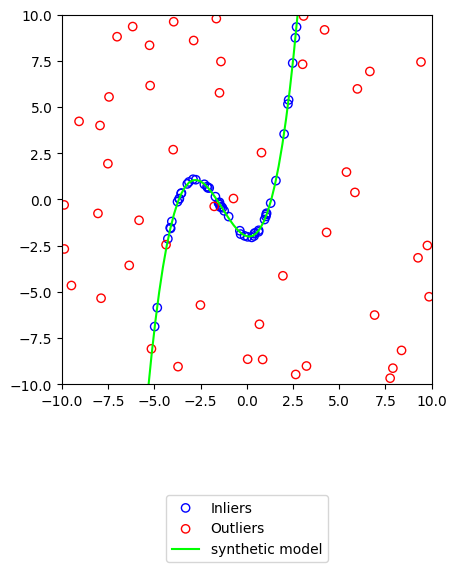

In [4]:
def plot_models(ax, inliers, outliers, synth_model: Polynomial, estimated_model: Optional[Polynomial] = None, title = None):
    ax.scatter(inliers[:, 0], inliers[:, 1], label="Inliers", c='none', edgecolors='blue')
    if outliers is not None:
        ax.scatter(outliers[:, 0], outliers[:, 1], label="Outliers", c='none', edgecolors='red')

    x = np.linspace(-10, 10, 100)[:, None]
    if estimated_model is not None:
        y = estimated_model.evaluate(x)
        ax.plot(x, y, color='black', label="estimated model")

    if title is not None:
        ax.set_title(title)

    y = synth_model.evaluate(x)
    ax.plot(x, y, color='lime', label='synthetic model')

    ax.set_ylim(bottom=-D, top=D)
    ax.set_xlim(left=-D, right=D)
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(0.5, -0.5), loc="lower center")

# Plotting the ground truth inliers/outliers
poly_a = Polynomial(np.array([-2, -0.25, 1, 0.25]))
inliers, outliers = poly_a.generate_points(0.5)
fig, ax = plt.subplots()
plot_models(ax, inliers, outliers, poly_a)
plt.show()
plt.close(fig)

In [5]:
%%time
# A simple non-complete test case for the data generation part
# It should not take more than a few seconds to run it.

test_points = np.array([[-5.01341822, -7.11485119],
                        [ 1.86544097,  2.59891622],
                        [-0.37093626, -1.7499924 ],
                        [-7.8621905 , -0.45595404]])

inliers, outliers = poly_a.generate_points(0.5, 1000000)
assert poly_a.is_inlier(inliers).all(), "Bad inliers"
assert (~poly_a.is_inlier(outliers)).all(), "Bad outliers"
assert np.abs(inliers).max() <= D, "Inliers outside of the domain"
assert np.abs(outliers).max() <= D, "Outliers outside of the domain"
assert (poly_a.is_inlier(test_points) == np.array([*([True] * 3), False])).all(), "Failed test case"

CPU times: user 780 ms, sys: 554 ms, total: 1.33 s
Wall time: 840 ms


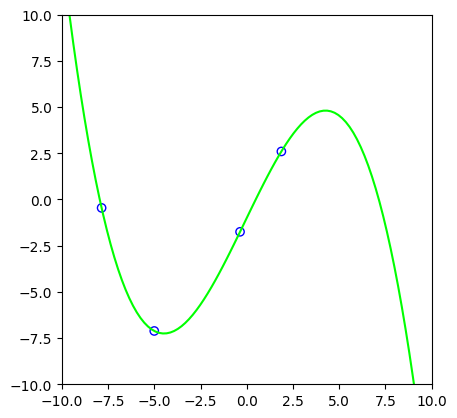

In [6]:
# Visualizing `fit` implementation. No need to edit this
def plot_fitted_poly(points, poly):
    fig, ax = plt.subplots()
    plot_models(ax, points, points[:0], poly)
    ax.get_legend().remove()
    plt.show()
    plt.close(fig)

poly = Polynomial.fit(test_points)

plot_fitted_poly(test_points, poly)

### 1.2. RANSAC

In [7]:
def get_ransac_iterations(r: float, sample_size: int, p: float) -> int:
    """
    r - outlier ratio
    sample_size - minimum data
    p - success rate

    Returns - number of RANSAC iterations to achieve `p` success rate
    """
    #n = 1

    # TODO : Compute the minimum number of RANSAC iterations necessary to achieve `p` success rate
    # START
    n = math.log(1-p)/math.log(1-(1-r)**sample_size)
    # END

    return math.ceil(n)

In [8]:
def run_ransac(points: np.ndarray, n_iter: int, sample_size: int) -> Tuple[np.ndarray, np.ndarray, Polynomial]:
    """
    points - Nx2 array with the data points
    n_iter - number of ransac iterations
    sample_size - number of samples required to fit the model

    Returns - tuple of inliers and outliers, each defined as Nx2 arrays of the
              respective points, and the final Polynomial model
    """

    n_points = points.shape[0]
    inliers = points[:0]
    outliers = points
    poly = None
    max_inlier_number = 0

    # TODO : Implement 1.2 - RANSAC for model fitting
    # START
    for i in range(n_iter):
      random_numbers = np.random.randint(0, int(n_points), size=sample_size)
      sample_points = points[random_numbers]
      fit_poly = Polynomial.fit(sample_points)
      check_inlier = fit_poly.is_inlier(points, tau)
      count = np.sum(check_inlier)
      if count>max_inlier_number:
        poly = fit_poly
        max_inlier_number = count
        inliers = points[check_inlier]
        outliers = points[~check_inlier]

    # fit the final polynomial using all inliers
    x_points = inliers[:,0].reshape(-1,1)
    y_points = inliers[:,1].reshape(-1,1)

    exponents = np.arange(0, sample_size, 1)
    X = x_points**exponents
    coefficients = np.linalg.inv(X.T @ X) @ X.T @ y_points
    coefficients = np.squeeze(coefficients)

    poly = Polynomial(coefficients)
    # END

    return inliers, outliers, poly

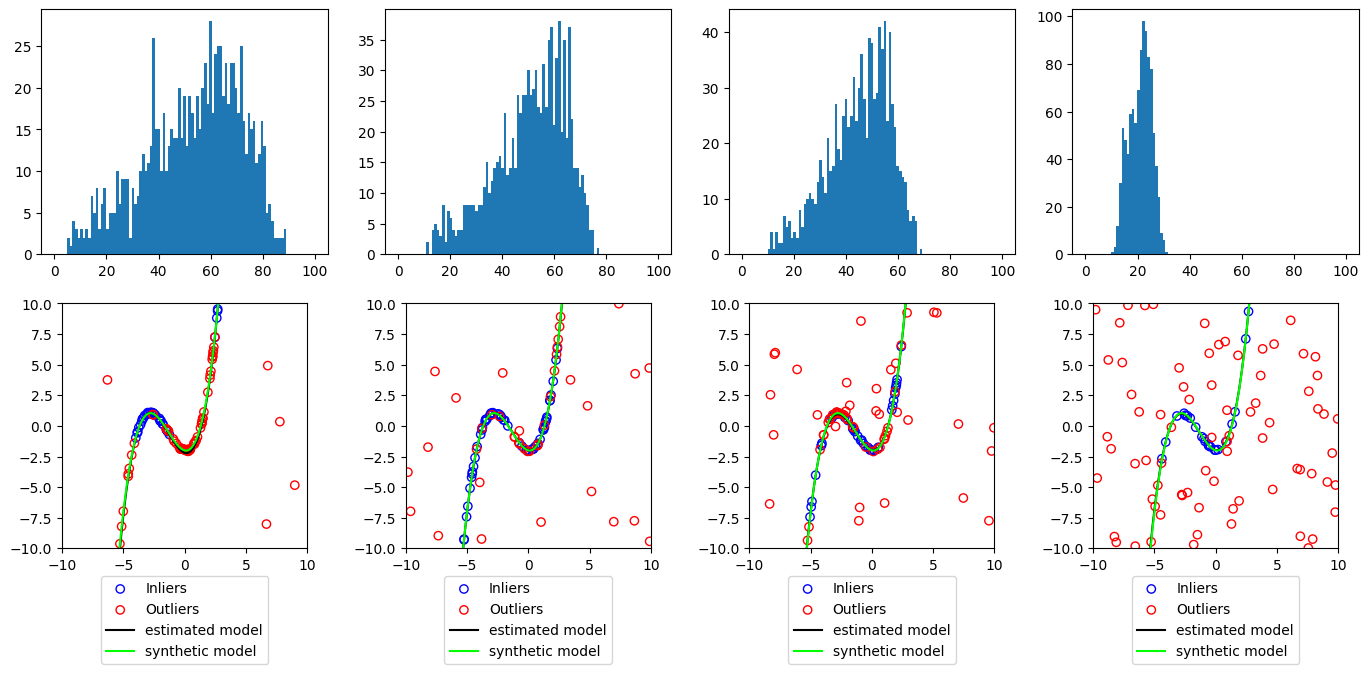

In [11]:
# Running RANSAC and populating historgrams
# It may take some time to run, you can adjust N_RUNS to help with debugging
N_RUNS = 1000
OUTLIER_RATIOS = [0.05, 0.2, 0.3, 0.7]

def plot_ransac_results(synth_poly: Polynomial):
    fig, axes = plt.subplots(2, len(OUTLIER_RATIOS), figsize=(17, 7))

    for r, (ax_hist, ax_vis) in zip(OUTLIER_RATIOS, zip(*axes)):
        inlier_histogram = np.zeros(N_RUNS)

        ransac_inliers = None
        ransac_outliers = None
        model = None

        # TODO : Fill `inlier_histogram` array and assign `ransac_inliers`,
        #        `ransac_outliers`, `model`
        # START
        sample_size = synth_poly.degree + 1
        n_iter = get_ransac_iterations(r, sample_size, 0.99)

        for i in range(N_RUNS):
          inliers, outliers = synth_poly.generate_points(r, N)
          points = np.concatenate((inliers, outliers), 0)
          ransac_inliers, ransac_outliers, model = run_ransac(points, n_iter, sample_size)
          n_inliers = ransac_inliers.shape[0]
          inlier_histogram[i] = n_inliers

        # END

        ax_hist.hist(inlier_histogram, range=(0, N), bins=N+1)

        plot_models(ax_vis, ransac_inliers, ransac_outliers, synth_poly, model)

    plt.show()
    plt.close(fig)


plot_ransac_results(poly_a)

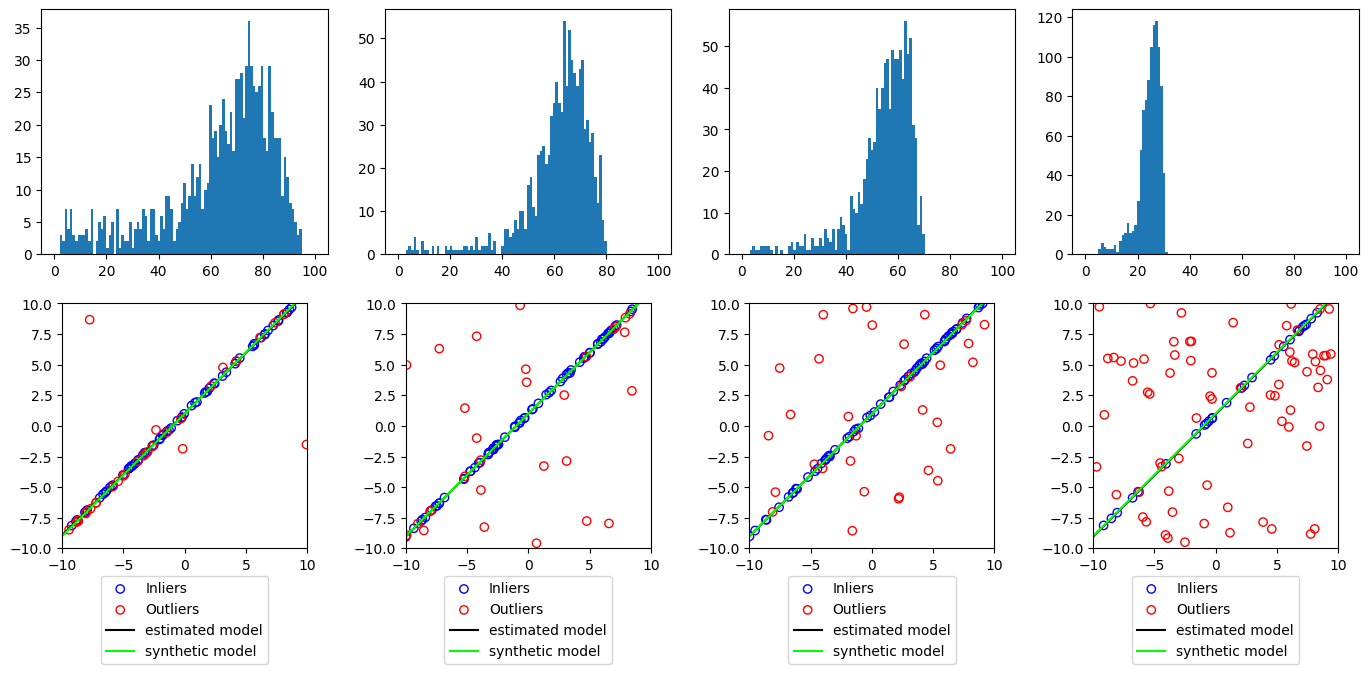

In [14]:
poly_b = Polynomial(np.array([1, 1]))
plot_ransac_results(poly_b)

### 1.3. Exhaustive search

In [15]:
def exhaustive_search(points: np.ndarray, sample_size) -> Tuple[np.ndarray, np.ndarray, Polynomial]:
    """
    points - Nx2 array with the data points
    sample_size - number of samples required to fit the model

    Returns - tuple of inliers and outliers, each defined as Nx2 arrays of the
              respective points, and the best model
    """

    n_points = points.shape[0]

    inliers = points[:0]
    outliers = points
    model = None

    # TODO : Implement exhaustive search by trying all the combinations of minimal data points
    # START
    combinations = np.array(list(itertools.combinations(range(n_points), sample_size)))
    max_inlier_number = 0

    for i in range(combinations.shape[0]):
      random_numbers = combinations[i]
      sample_points = points[random_numbers]
      fit_poly = Polynomial.fit(sample_points)
      check_inlier = fit_poly.is_inlier(points, tau)
      count = np.sum(check_inlier)
      if count>max_inlier_number:
        max_inlier_number = count
        model = fit_poly
        inliers = points[check_inlier]
        outliers = points[~check_inlier]

    # fit the final polynomial using all inliers
    x_points = inliers[:,0].reshape(-1,1)
    y_points = inliers[:,1].reshape(-1,1)

    exponents = np.arange(0, sample_size, 1)
    X = x_points**exponents
    coefficients = np.linalg.inv(X.T @ X) @ X.T @ y_points
    coefficients = np.squeeze(coefficients)

    model = Polynomial(coefficients)
    # END

    return inliers, outliers, model

Real inliers: 24
RANSAC inliers: 11
Exhaustive search inliers: 24


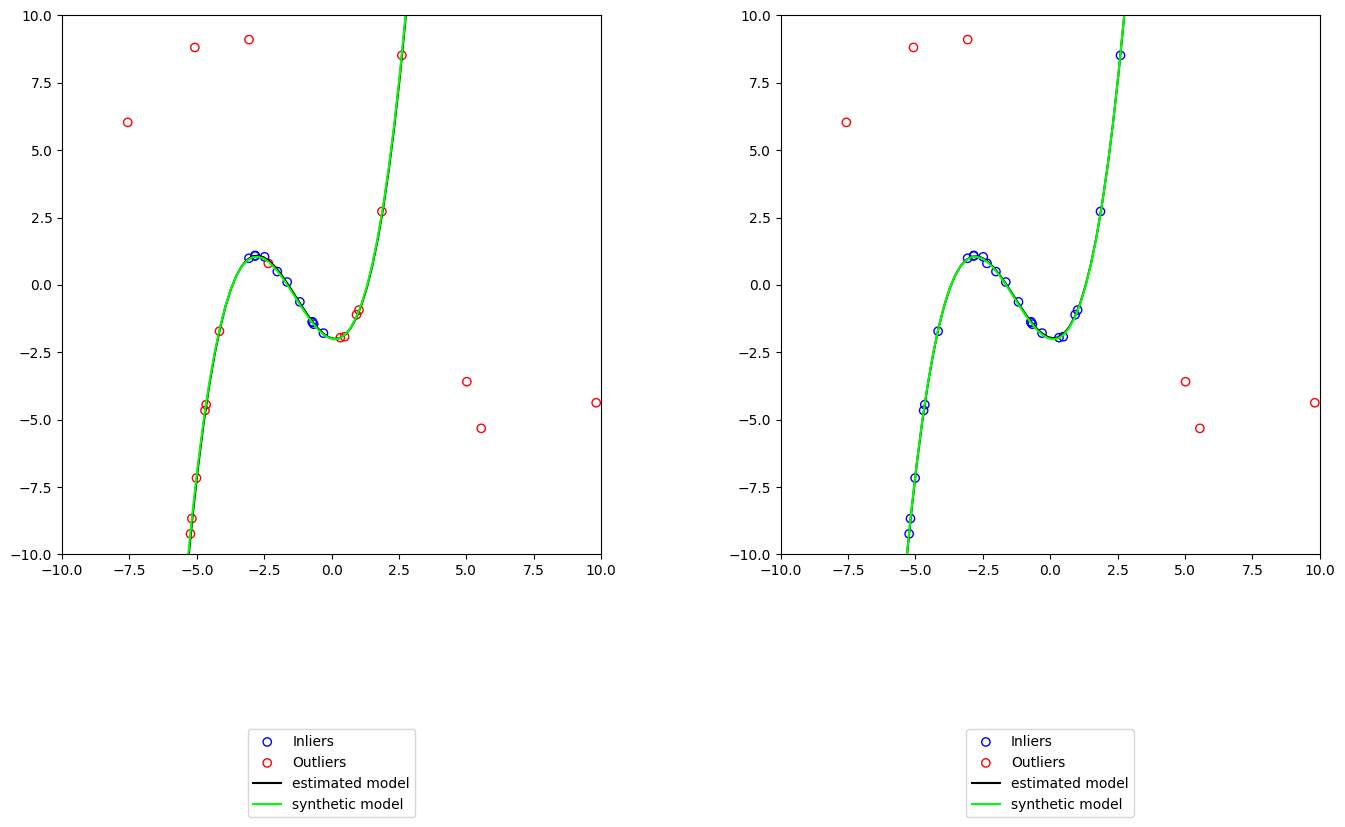

In [16]:
# Running exhaustive search. No need to edit this. Running on a reduced set of points
inliers, outliers = poly_a.generate_points(0.2, 30)
points = np.concatenate((inliers, outliers), 0)

sample_size = poly_a.degree + 1
n_iter = get_ransac_iterations(0.2, sample_size, 0.99)
ransac_inliers, ransac_outliers, ransac_model = run_ransac(points, n_iter, sample_size)

exhaustive_inliers, exhaustive_outliers, exhaustive_model = exhaustive_search(points, sample_size)

print(f"Real inliers: {len(inliers)}")
print(f"RANSAC inliers: {len(ransac_inliers)}")
print(f"Exhaustive search inliers: {len(exhaustive_inliers)}")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

plot_models(axes[0], ransac_inliers, ransac_outliers, poly_a, ransac_model)
plot_models(axes[1], exhaustive_inliers, exhaustive_outliers, poly_a, exhaustive_model)

plt.show()
plt.close(fig)

### Questions and Discussion

<b style="color:red"> Question 1.1: </b> How many combinations (exhaustive search) exist for $N=100$ points?

In general we have N choose sample_size combinations. Here we have 100 choose 4, which is 3921225 combinations.

<b style="color:red"> Question 1.2: </b> What about the number of RANSAC iterations with $r=5\%$, $20\%$, $30\%$ and $70\%$?

In theory, there is also N choose sample_size combinations avaliable. But only at most n_iter of them are used in RANSAC, since we have n_iter iterations and the random samples from the iterations might overlap.

<b style="color:red"> Question 1.3: </b> What about when $N=100,000$ points?

Again, we have N choose sample_size combinations, in this case 4166416671249975000 combinations.

<b style="color:red"> Question 1.4: </b> Does exhaustive search on all the combinations of data points guarantee the optimal solution (in terms of number of inliers)? Why?

As long as there is sample_size inliers among all samples, this combination with all inliers will be used to calculate a coefficient that is correct up to random noise. The generated inliers also lie within coefficient's function's inlier range up to random noise. Even though the inlier number is not always the same as generated inlier number, they should be quite close.

<b style="color:red"> Question 1.5: </b> Does RANSAC always find close to the optimal number of inliers? Why? If not, would increasing the number of RANSAC iterations always improve that?

No. In our calculation, with 99% probability we have a sample with no outliers, with this sample, the correct coefficient could be calculated up to random noise. So there is still possibility that we won't get such a sample. Increase the number of RANSAC iterations could help, but not always. According to the formula: N = log(1-p)/log(1-(1-sigma)^s)), we could never get p equal 1 if sigma is smaller than one (meaning if we have outliers).

<b style="color:red"> Question 1.6: </b> Discuss and compare the results obtained by RANSAC and exhaustive search in terms of
number of inliers, speed, number of synthesized inliers, etc.

The speed of RANSAC is faster than exhaustive search, since we execute the inner loop in RANSAC n_iter iterations, but in exhaustive search all possible combination iterations. Then combinations tested in RANSAC is a subset of the ones in exhaustive search. The number of inliers of exhaustive search is more than the one of RANSAC.

<b style="color:red"> Question 1.7: </b> One of the challenges in using RANSAC for fitting polynomials is choosing appropriate values for the number of iterations and the inlier threshold. How would you go about selecting these values, and what factors should you consider when making this choice? Describe any tradeoffs that may exist between these two parameters, and provide an example scenario where a higher number of iterations or a higher inlier threshold might be preferable.

The number of iterations are closely connected to how good the result we need and how much inliers we have (like the formula: N = log(1-p)/log(1-(1-sigma)^s))). Since more iterations lead to more computation, it also depends on the available computation resources.

The inlier threshold should be chosen based on the expected noise level of the data. It also depend on the model complexity, for more complex models we might need smaller threshold to capture their behavior correctly. The outlier ratio also plays a role here. For high outlier ratio, a smaller threshold may be necessary to effectively separate inliers from outliers.

Having a small inlier threshold can lead more needed iterations. With a small inlier threshold, more data points are judged to be outliers, then we need more iterations to have a all-inlier sample (again, as in the formula: N = log(1-p)/log(1-(1-sigma)^s))).

When fitting a polynomial model to noisy data with a significant proportion of outliers, we might choose a higher number of iterations to increase the chance of finding a good set of inliers. Additionally, we might need a smaller inlier threshold to ensure that the model accurately captures the underlying polynomial structure while effectively filtering out outliers.

## Part 2: IRLS and norms for line fitting

In [17]:
poly_b = Polynomial(np.array([1, 1]))

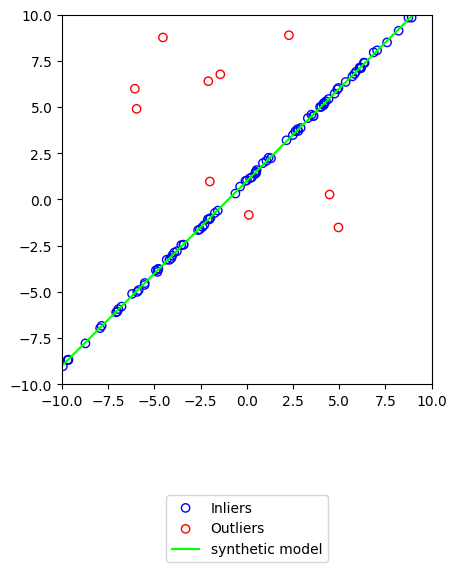

In [18]:
# Plotting the generated line that will be used for model fitting, no need to change this code
inliers, outliers = poly_b.generate_points(0.1)
points = np.concatenate((inliers, outliers), 0)

fig, ax = plt.subplots()
plot_models(ax, inliers, outliers, poly_b)
plt.show()
plt.close(fig)

In [19]:
## Implement different line fitting algorithms

def fit_line_irls_l1(points: np.ndarray) -> Polynomial:
    """
    points - Nx2 array with the data points

    Returns - fitted Line
    """

    line = np.array([0, 0.5])

    # TODO : Implement line fitting with L-1 norm by using IRLS
    # START
    n_points = points.shape[0]
    X = np.ones((n_points, 2))
    X[:,1] = points[:,0]
    points_y = points[:,1].reshape(-1,1)
    diff = 10

    # recalculate the weight matrix and the coefficient according to (X.T@W@X)^-1@X.T@W@points_y
    # until the difference between two consecutive coefficients is small enough
    while diff > 0.001:
      f_x = X @ line.reshape(-1, 1)
      w = np.abs(f_x - points_y)**(-1)
      W = np.diagflat(w)
      coefficients = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ points_y
      diff = np.sum(np.abs(line - coefficients.squeeze()))
      line = coefficients.squeeze()
    # END

    return Polynomial(line)


def fit_line_lp_l1(points: np.ndarray) -> Polynomial:
    """
    points - Nx2 array with the data points

    Returns - fitted Line
    """
    line = np.array([0, 0.5])

    # TODO : Implement line fitting with L-1 norm by using linear programming
    # START
    n_points = points.shape[0]
    points_y = points[:,1].reshape(-1,1)

    # c: first two for b, a; rest for t_0:t_n-1
    c = np.ones((n_points+2,))
    c[0] = 0
    c[1] = 0

    # A_ub_1 for b+a*x_i-t_i<=y_i
    # A_ub_2 for -b-a*x_i-t_i<=-y_i
    X = np.ones((n_points, 2))
    X[:,1] = points[:,0]
    diagonal_matrix = np.diag(-np.ones(n_points))
    A_ub_1 = np.hstack((X, diagonal_matrix))
    A_ub_2 = np.hstack((-X, diagonal_matrix))
    A_ub = np.vstack((A_ub_1, A_ub_2))
    b_ub = np.vstack((points_y, -points_y))

    # a and b have no bounds, t_0:t_n-1 has bounds (0, None)
    bounds = [(None, None)] * 2
    bounds += [(0, None)] * n_points

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds)
    line = res.x[:2]
    # END

    return Polynomial(line)


def fit_line_lp_l_inf(points: np.ndarray) -> Polynomial:
    """
    points - Nx2 array with the data points

    Returns - fitted Line
    """
    line = np.array([0, 0.5])

    # TODO : Implement line fitting with L-infinity norm by using linear programming
    # START
    n_points = points.shape[0]
    points_y = points[:,1].reshape(-1,1)

    # c: first two for b, third for t
    c = np.zeros((3,))
    c[2] = 1

    # A_ub_1 for b+a*x_i-t<=y_i
    # A_ub_2 for -b-a*x_i-t<=-y_i
    X = np.ones((n_points, 2))
    X[:,1] = points[:,0]
    minus_t = -np.ones((n_points,1))
    A_ub_1 = np.hstack((X, minus_t))
    A_ub_2 = np.hstack((-X, minus_t))
    A_ub = np.vstack((A_ub_1, A_ub_2))
    b_ub = np.vstack((points_y, -points_y))

    # a and b have no bounds, t_0:t_n-1 has bounds (0, None)
    bounds = [(None, None)] * 2
    bounds += [(0, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds)
    line = res.x[:2]
    # END

    return Polynomial(line)

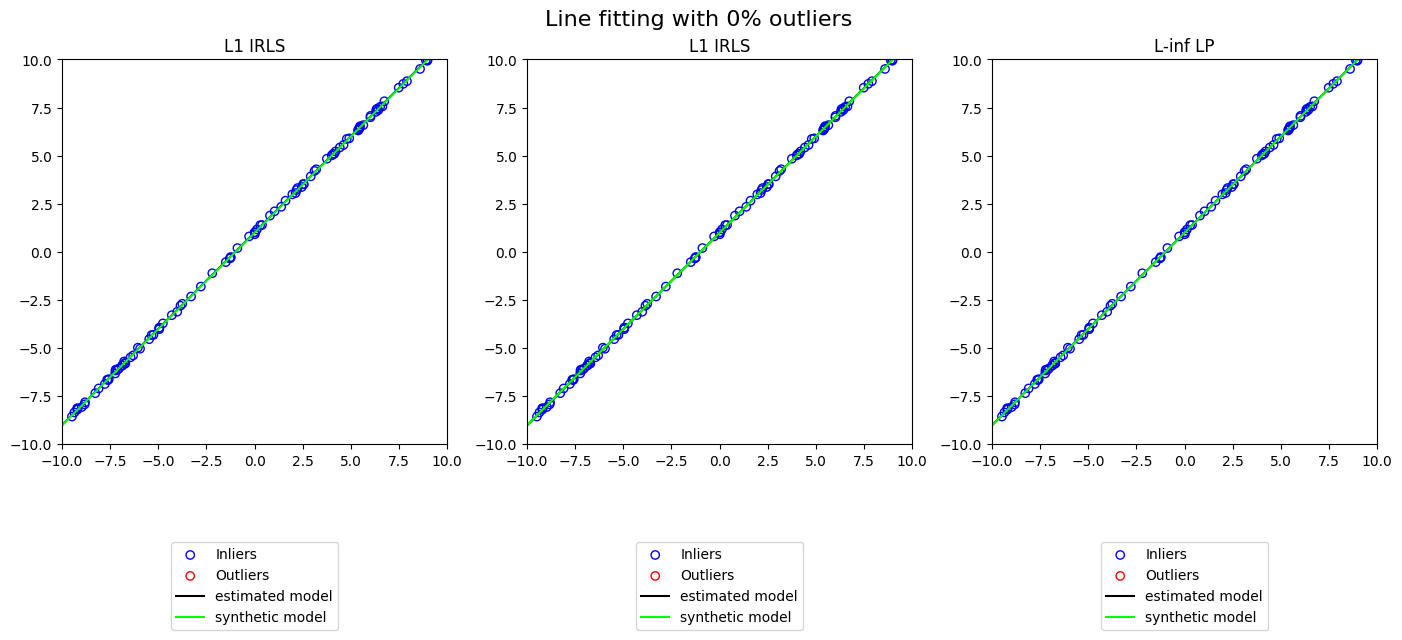

IRLS L1: Polynomial([1.0144244164172462, 1.0006210509965898])
LP L1: Polynomial([0.9996845721567557, 1.0011382125803152])
LP L-inf: Polynomial([1.001216003142444, 0.9999854758452758])


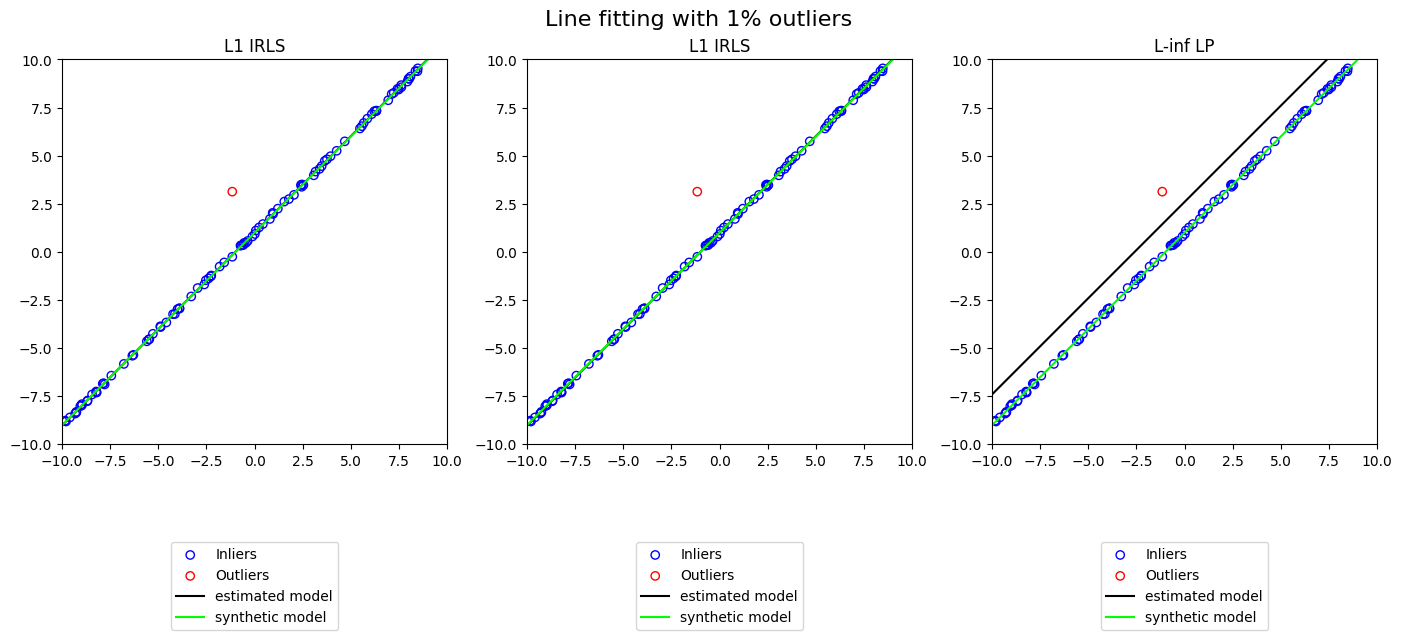

IRLS L1: Polynomial([1.0065202883220965, 1.001652885373273])
LP L1: Polynomial([1.000764799676424, 1.002579054915018])
LP L-inf: Polynomial([2.5991181762199735, 0.9998183877440457])


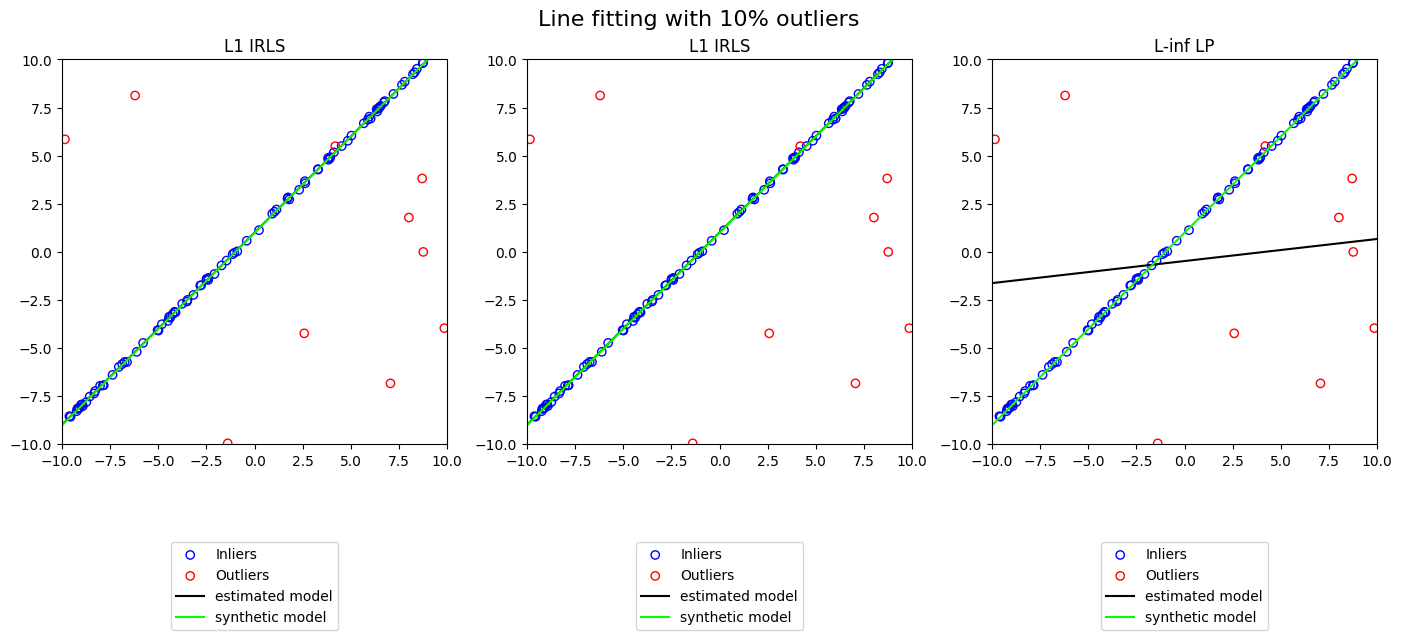

IRLS L1: Polynomial([1.0096418024766427, 0.9983890236787644])
LP L1: Polynomial([1.01431585737771, 0.9996061882592739])
LP L-inf: Polynomial([-0.47237832615864783, 0.11457738493596326])


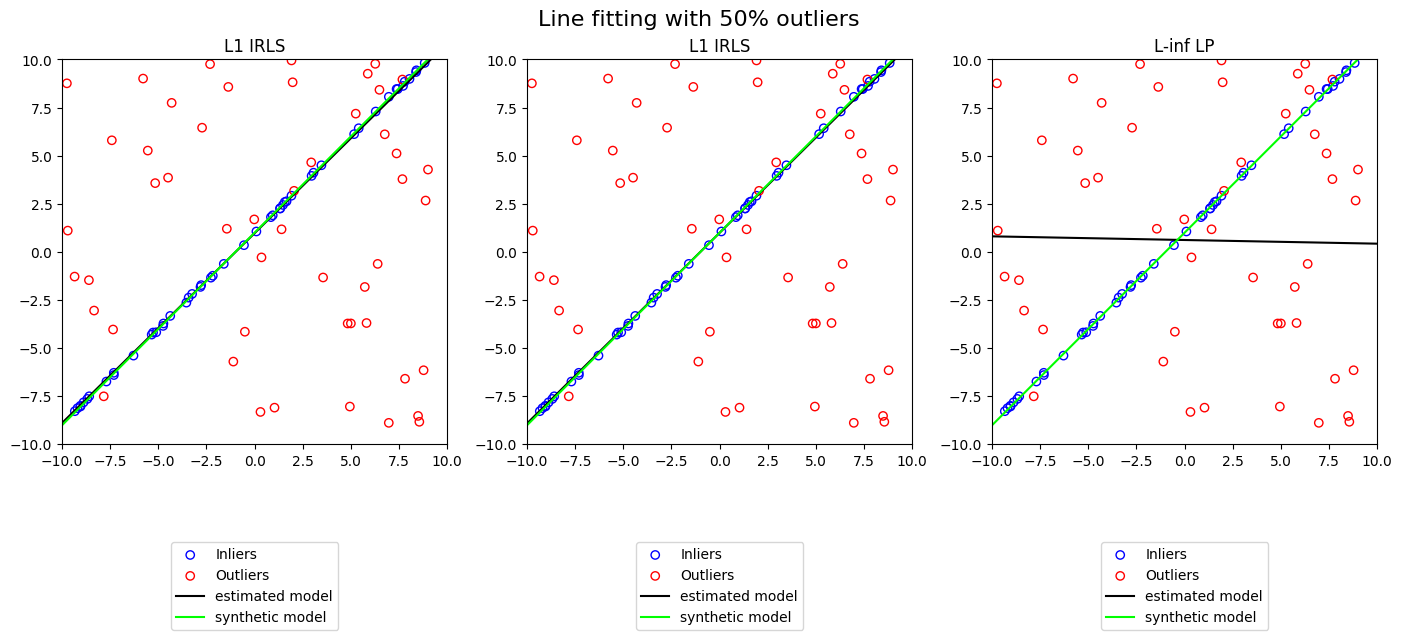

IRLS L1: Polynomial([0.9745611637744762, 0.9857674361621585])
LP L1: Polynomial([0.99203874026447, 0.9897099026226959])
LP L-inf: Polynomial([0.6201838927750878, -0.019036578106491554])


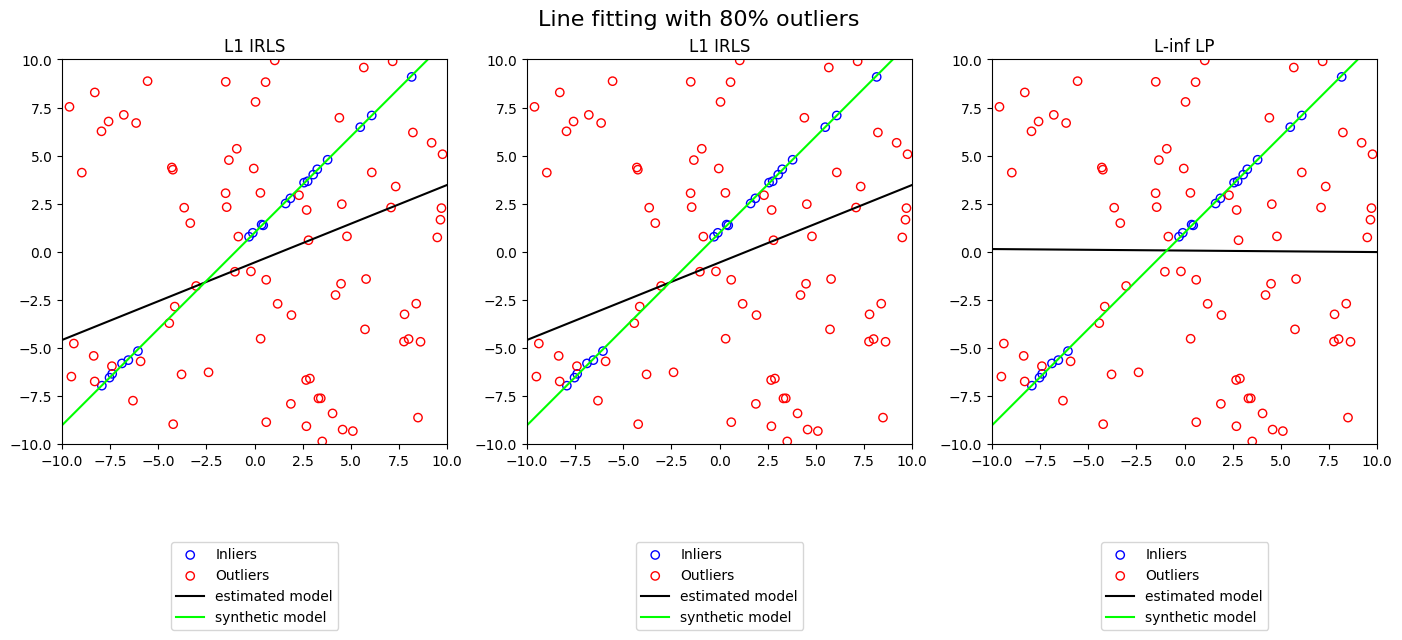

IRLS L1: Polynomial([-0.5460715533927638, 0.4025423329133938])
LP L1: Polynomial([-0.5457525028356054, 0.4024971454311462])
LP L-inf: Polynomial([0.072036165339935, -0.007843025613799823])


In [20]:
# Plotting the results. No need to change this code
for r in [0.0, 0.01, 0.1, 0.5, 0.8]:
    inliers, outliers = poly_b.generate_points(r)
    points = np.concatenate((inliers, outliers), 0)

    irls_l1_line = fit_line_irls_l1(points)
    lp_l1_line = fit_line_lp_l1(points)
    lp_l_inf_line = fit_line_lp_l_inf(points)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    fig.suptitle(f'Line fitting with {r*100:.0f}% outliers', fontsize=16)

    plot_models(axes[0], inliers, outliers, poly_b, irls_l1_line, title="L1 IRLS")
    plot_models(axes[1], inliers, outliers, poly_b, lp_l1_line, title="L1 IRLS")
    plot_models(axes[2], inliers, outliers, poly_b, lp_l_inf_line, title="L-inf LP")

    plt.show()
    plt.close(fig)

    print(f"IRLS L1: {irls_l1_line}")
    print(f"LP L1: {lp_l1_line}")
    print(f"LP L-inf: {lp_l_inf_line}")


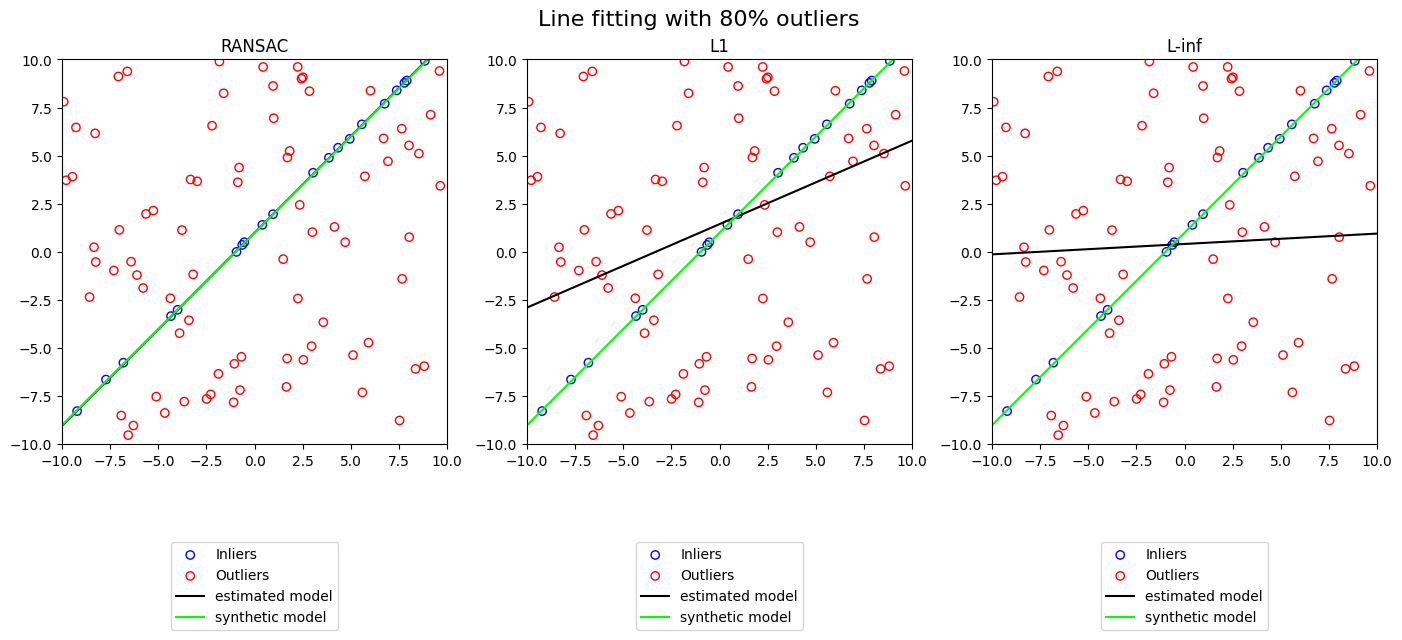

In [22]:
# Comparison with RANSAC
r = 0.8
inliers, outliers = poly_b.generate_points(r)
points = np.concatenate((inliers, outliers), 0)

sample_size = poly_b.degree + 1
n_iter = get_ransac_iterations(r, sample_size, 0.99)
_, _, ransac_line = run_ransac(points, n_iter, sample_size)

lp_l1_line = fit_line_lp_l1(points)
lp_l_inf_line = fit_line_lp_l_inf(points)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fig.suptitle(f'Line fitting with {r*100:.0f}% outliers', fontsize=16)

plot_models(axes[0], inliers, outliers, poly_b, ransac_line, title="RANSAC")
plot_models(axes[1], inliers, outliers, poly_b, lp_l1_line, title="L1")
plot_models(axes[2], inliers, outliers, poly_b, lp_l_inf_line, title="L-inf")

plt.show()
plt.close(fig)

### Discussion

<b style="color:red"> Question 2.1:</b> Discuss the results obtained by IRLS/LP solutions.

IRLS L1 and LP L1 are more robust to outliers, they perform quite well from 0 to 50% outlier ratio. LP L-inf is not robust to outliers, it only gives correct results when no outlier appears.

<b style="color:red"> Question 2.2:</b> Compare and contrast them with RANSAC. What are the key differences between these two approaches? Under what circumstances might one be more suitable than the other?

The RANSAC method is much more robust to outliers compared to IRLS/LP methods. RANSAC method tries to find an optimal solution depending only on inliers, where both IRLS/LP methods still depend on outliers. IRLS L1 and LP L1 are quite simliar, they both minimize the L1 norm of differences. However, LP L1 is much more efficient, since IRLS L1 requires complex matrix calculations for many iterations. LP L-inf is much less robust to outliers compared to all the other ones, it pays more attention to outliers, since the only "t" depends highly on the outliers.

For cases where we want to ignore outliers and reduce their impact as small as possible, RANSAC is always the best choice among them, efficient and good performance. With little outliers, IRLS L1 and LP L1 are still suitable, but LP L1 is more efficient. For cases where we want to take outliers into consideration, IRLS/LP are more suitable.